# Useful tools:

In [1]:
import torch
import numpy as np
import matplotlib.patches as patches
import matplotlib.pyplot as plt
import cv2
import torch.nn as nn

def DisplayImage(img):
    image = cv2.cvtColor(img.copy(), cv2.COLOR_BGR2RGB)
    # fig, ax = plt.subplots(1, figsize=(6, 8))
    # image = np.transpose(image.copy(), (1, 2, 0))
    fig, ax = plt.subplots(1)
    ax.imshow(image)
    plt.show()

def DisplayLabel(img, bboxs):
    # image = np.transpose(image.copy(), (1, 2, 0))
    # fig, ax = plt.subplots(1, figsize=(6, 8))
    image = cv2.cvtColor(img.copy(), cv2.COLOR_BGR2RGB)
    fig, ax = plt.subplots(1)
    edgecolor = [1, 0, 0]
    if len(bboxs) == 1:
        bbox = bboxs[0]
        ax.add_patch(patches.Rectangle((bbox[0] - bbox[2]/2, bbox[1] - bbox[3]/2), bbox[2], bbox[3], linewidth=1, edgecolor=edgecolor, facecolor='none'))
    elif len(bboxs) > 1:
        for bbox in bboxs:
            ax.add_patch(patches.Rectangle((bbox[0] - bbox[2]/2, bbox[1] - bbox[3]/2), bbox[2], bbox[3], linewidth=1, edgecolor=edgecolor, facecolor='none'))
    ax.imshow(image)
    plt.show()


# Load data:

In [2]:
from pathlib import Path
import os
import numpy as np

print("Current working directory:")
print(os.getcwd())

# Search current folder and parent folder
search_roots = [
    Path("."),
    Path(".."),
]

matches = []
for root in search_roots:
    matches.extend(list(root.rglob("labels.npy")))

# Remove duplicates
matches = sorted(set([m.resolve() for m in matches]))

print("\nFound labels.npy files:")
for m in matches:
    print(m)

if len(matches) == 0:
    raise FileNotFoundError(
        "Could not find labels.npy. Move the extracted f110_dataset_20220209 folder "
        "into your deep_learning_project folder, or search from the correct parent directory."
    )

labels_path = matches[0]
dataset_folder = str(labels_path.parent) + os.sep

print("\nUsing dataset_folder:")
print(dataset_folder)

labels = np.load(labels_path)
print("Number of labels:", len(labels))

Current working directory:
c:\Users\ishan\OneDrive\Desktop\Code\deep_learning_project\notebooks

Found labels.npy files:
C:\Users\ishan\OneDrive\Desktop\Code\deep_learning_project\data\f110_dataset_20220209\labels.npy

Using dataset_folder:
C:\Users\ishan\OneDrive\Desktop\Code\deep_learning_project\data\f110_dataset_20220209\
Number of labels: 1792


In [25]:
final_dim = [5, 10]
input_dim = [180, 320]
anchor_size = [(input_dim[0] / final_dim[0]), (input_dim[1] / final_dim[1])]
arr = np.arange(labels.shape[0])
np.random.shuffle(arr)

# convert feature map coord to image coord
def grid_cell(cell_indx, cell_indy):
    stride_0 = anchor_size[1]
    stride_1 = anchor_size[0]
    return np.array([cell_indx * stride_0, cell_indy * stride_1, cell_indx * stride_0 + stride_0, cell_indy * stride_1 + stride_1])

# convert from [c_x, c_y, w, h] to [x_l, y_l, x_r, y_r]
def bbox_convert(c_x, c_y, w, h):
    return [c_x - w/2, c_y - h/2, c_x + w/2, c_y + h/2]

# convert from [x_l, y_l, x_r, x_r] to [c_x, c_y, w, h]
def bbox_convert_r(x_l, y_l, x_r, y_r):
    return [x_l/2 + x_r/2, y_l/2 + y_r/2, x_r - x_l, y_r - y_l]

# calculating IoU
def IoU(box_a, box_b):
    """
    box_a and box_b are [x1, y1, x2, y2].
    Returns scalar IoU.
    """
    xA = max(float(box_a[0]), float(box_b[0]))
    yA = max(float(box_a[1]), float(box_b[1]))
    xB = min(float(box_a[2]), float(box_b[2]))
    yB = min(float(box_a[3]), float(box_b[3]))

    inter_w = max(0.0, xB - xA)
    inter_h = max(0.0, yB - yA)
    inter_area = inter_w * inter_h

    area_a = max(0.0, float(box_a[2]) - float(box_a[0])) * max(0.0, float(box_a[3]) - float(box_a[1]))
    area_b = max(0.0, float(box_b[2]) - float(box_b[0])) * max(0.0, float(box_b[3]) - float(box_b[1]))

    union = area_a + area_b - inter_area
    #add safety measure for dividing by zero
    if union <= 1e-8:
        return 0.0

    return inter_area / union

def assign_label(label):
    label_gt = np.zeros((5, final_dim[0], final_dim[1]))
    IoU_threshold = 0.01
    IoU_max = 0
    IoU_max_ind = [0, 0]

    for ind_row in range(final_dim[0]):
        for ind_col in range(final_dim[1]):
            label_assign = 0
            grid_info = grid_cell(ind_col, ind_row)
            label_bbox = bbox_convert(label[0], label[1], label[2], label[3])
            IoU_value = IoU(label_bbox, grid_info)
            if IoU_value > IoU_threshold:
                label_assign = 1
            if IoU_value > IoU_max:
                IoU_max = IoU_value
                IoU_max_ind[0] = ind_row
                IoU_max_ind[1] = ind_col

            # construct the gt vector
            if label_assign == 1:
                label_gt[0, ind_row, ind_col] = 1
                label_gt[1, ind_row, ind_col] = label[0] - (grid_info[0] + anchor_size[1]/2)
                label_gt[2, ind_row, ind_col] = label[1] - (grid_info[1] + anchor_size[0]/2)
                label_gt[3, ind_row, ind_col] = label[2] / float(input_dim[1])
                label_gt[4, ind_row, ind_col] = label[3] / float(input_dim[0])
    
    grid_info = grid_cell(IoU_max_ind[0], IoU_max_ind[1])
    label_gt[0, IoU_max_ind[0], IoU_max_ind[1]] = 1
    label_gt[1, IoU_max_ind[0], IoU_max_ind[1]] = label[0] - (grid_info[0] + anchor_size[1]/2)
    label_gt[2, IoU_max_ind[0], IoU_max_ind[1]] = label[1] - (grid_info[1] + anchor_size[0]/2)
    label_gt[3, IoU_max_ind[0], IoU_max_ind[1]] = label[2] / float(input_dim[1])
    label_gt[4, IoU_max_ind[0], IoU_max_ind[1]] = label[3] / float(input_dim[0])
    return label_gt

# Due to the small size of dataset, we preprocess them into memory to speed up training.
images = []
for ind in range(labels.shape[0]):
    img_path = dataset_folder + str(ind) + '.jpg'
    img = cv2.imread(img_path) / 255.0
    img = cv2.resize(img, (input_dim[1], input_dim[0]))
    images.append(img)

# Construct datasets
class F110Dataset(torch.utils.data.Dataset):
    def __init__(self, indices, folder, labels):
        self.folder = folder
        self.labels = labels
        self.indices = np.asarray(indices, dtype=int)

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, index):
        sample_idx = self.indices[index]

        # Original labels are for 640x360 images.
        # Notebook resizes images to 320x180, so divide by 2.
        label = self.labels[sample_idx].copy() / (360.0 / input_dim[0])

        label_gt = np.asarray(assign_label(label))

        img_np = images[sample_idx]
        img_np = np.transpose(img_np, (2, 0, 1))

        return (
            torch.from_numpy(img_np).type("torch.FloatTensor"),
            torch.from_numpy(label_gt).type("torch.FloatTensor"),
            label,
        )

train_indices = np.load("../splits/train_indices.npy")
val_indices = np.load("../splits/val_indices.npy")

train_set = F110Dataset(train_indices, dataset_folder, labels)
validation_set = F110Dataset(val_indices, dataset_folder, labels)

train_loader = torch.utils.data.DataLoader(dataset=train_set, batch_size=1, shuffle=True)
validation_loader = torch.utils.data.DataLoader(dataset=validation_set, batch_size=1, shuffle=False)

print("Train samples:", len(train_set))
print("Validation samples:", len(validation_set))

Train samples: 1433
Validation samples: 359


(3, 180, 320)
tensor([207.2500,  57.5000,  85.5000,  51.0000], dtype=torch.float64)
tensor([[0., 0., 0., 0., 0., 1., 1., 1., 0., 0.],
        [0., 0., 0., 0., 0., 1., 1., 1., 0., 0.],
        [0., 0., 0., 0., 0., 1., 1., 1., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]])
tensor([[207.2500,  57.5000,  85.5000,  51.0000]], dtype=torch.float64)


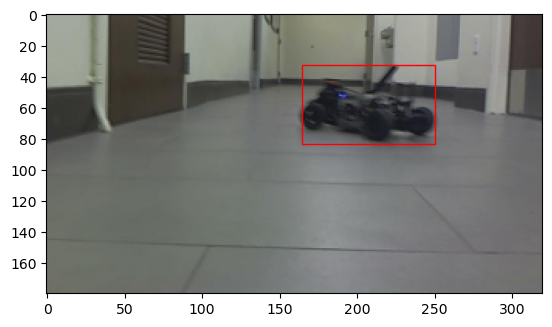

In [4]:
## Plot one label to see if it's correct.

for data_ind, data_list in enumerate(train_loader):
    if data_ind == 0:
        image = data_list[0]
        label_gt = data_list[1]
        label = data_list[2]
        break
print(image[0].numpy().shape)
print(label[0])
print(label_gt[0][0])
print(label)
DisplayLabel(np.transpose(image[0].numpy(), (1, 2, 0)), label)

# Model Definition

In [ ]:
class F110_YOLO(torch.nn.Module):
    def __init__(self):
        super(F110_YOLO, self).__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size = 4, padding = 1, stride = 2)
        self.batchnorm1 = nn.BatchNorm2d(16)
        self.relu1 = nn.ReLU(inplace = True)

        self.conv2 = nn.Conv2d(16, 32, kernel_size = 4, padding = 1, stride = 2)
        self.batchnorm2 = nn.BatchNorm2d(32)
        self.relu2 = nn.ReLU(inplace = True)

        self.conv3 = nn.Conv2d(32, 32, kernel_size = 4, padding = 1, stride = 2)
        self.batchnorm3 = nn.BatchNorm2d(32)
        self.relu3 = nn.ReLU(inplace = True)
        
        self.conv4 = nn.Conv2d(32, 64, kernel_size = 4, padding = 1, stride = 2)
        self.batchnorm4 = nn.BatchNorm2d(64)
        self.relu4 = nn.ReLU(inplace = True)

        self.conv5 = nn.Conv2d(64, 64, kernel_size = 4, padding = 1, stride = 2)
        self.batchnorm5 = nn.BatchNorm2d(64)
        self.relu5 = nn.ReLU(inplace = True)

        self.conv6 = nn.Conv2d(64, 32, kernel_size = 3, padding = 1, stride = 1)
        self.batchnorm6 = nn.BatchNorm2d(32)
        self.relu6 = nn.ReLU(inplace = True)

        self.conv7 = nn.ConvTranspose2d(32, 32, kernel_size = 3, padding = 1, stride = 1)
        self.batchnorm7 = nn.BatchNorm2d(32)
        self.relu7 = nn.ReLU(inplace = True)

        self.conv8 = nn.ConvTranspose2d(32, 16, kernel_size = 3, padding = 1, stride = 1)
        self.batchnorm8 = nn.BatchNorm2d(16)
        self.relu8 = nn.ReLU(inplace = True)

        self.conv9 = nn.Conv2d(16, 5, kernel_size = 1, padding = 0, stride = 1)
        self.relu9 = nn.ReLU()
    
    def forward(self, x):
        debug = 0 # change this to 1 if you want to check network dimensions
        if debug == 1: print(0, x.shape)
        x = torch.relu(self.batchnorm1(self.conv1(x)))
        if debug == 1: print(1, x.shape)
        x = torch.relu(self.batchnorm2(self.conv2(x)))
        if debug == 1: print(2, x.shape)
        x = torch.relu(self.batchnorm3(self.conv3(x)))
        if debug == 1: print(3, x.shape)
        x = torch.relu(self.batchnorm4(self.conv4(x)))
        if debug == 1: print(4, x.shape)
        x = torch.relu(self.batchnorm5(self.conv5(x)))
        if debug == 1: print(5, x.shape)
        x = torch.relu(self.batchnorm6(self.conv6(x)))
        if debug == 1: print(6, x.shape)
        x = torch.relu(self.batchnorm7(self.conv7(x)))
        if debug == 1: print(7, x.shape)
        x = torch.relu(self.batchnorm8(self.conv8(x)))
        if debug == 1: print(8, x.shape)
        x = self.conv9(x)
        if debug == 1: print(9, x.shape)
        x = torch.cat([x[:, 0:3, :, :], torch.sigmoid(x[:, 3:5, :, :])], dim=1)

        return x

    def get_loss(self, result, truth, lambda_coord = 5, lambda_noobj = 1):
        x_loss = (result[:, 1, :, :] - truth[:, 1, :, :]) ** 2
        y_loss = (result[:, 2, :, :] - truth[:, 2, :, :]) ** 2
        w_loss = (torch.sqrt(result[:, 3, :, :]) - torch.sqrt(truth[:, 3, :, :])) ** 2
        h_loss = (torch.sqrt(result[:, 4, :, :]) - torch.sqrt(truth[:, 4, :, :])) ** 2
        class_loss_obj = truth[:, 0, :, :] * (truth[:, 0, :, :] - result[:, 0, :, :]) ** 2
        class_loss_noobj = (1 - truth[:, 0, :, :]) * lambda_noobj * (truth[:, 0, :, :] - result[:, 0, :, :]) ** 2

        total_loss = torch.sum(lambda_coord * truth[:, 0, :, :] * (x_loss + y_loss + w_loss + h_loss) + class_loss_obj + class_loss_noobj)
        
        return total_loss


# Train your network

Save checkpoints and reload from the most recent. This is due to time constraints inside of colab.

In [14]:
## Begin training the model
train_loss_record = []
validation_loss_record = []
device = torch.device('cuda')
model = F110_YOLO().to(device)

In [15]:
## Training Process
batch_size = 16 
epochs = 300
lr = 0.001

train_loader = torch.utils.data.DataLoader(dataset=train_set, batch_size=batch_size, shuffle=True)
optimizer = torch.optim.Adam(model.parameters(), lr=lr)

for epoch in range(epochs):
    model.to(device)
    model.train()
    train_loss = []
    validation_loss = []
    # ind = 0

    time_train = 0
    for image_t, label_t, _ in train_loader:     
        image_t = image_t.to(device)
        label_t = label_t.to(device)
        optimizer.zero_grad()
        
        result = model(image_t)
        loss = model.get_loss(result, label_t)
        
        loss.backward()
        optimizer.step()
        train_loss.append(loss.item()/batch_size)        
    train_loss_record.append(np.average(train_loss))

    ## validationing
    model.eval()
    object_in_class = 0
    truth_in_class = 0
    for image_t, label_t, _ in validation_loader:
        image_t = image_t.to(device)
        label_t = label_t.to(device)
        result = model(image_t)
        loss = model.get_loss(result, label_t)
        validation_loss.append(loss.item())

    validation_loss_record.append(np.average(validation_loss))
    print("total epoch:", len(train_loss_record), '| train_loss:', np.average(train_loss), '| validation_loss:', np.average(validation_loss), )

# save the model
model_save_name = 'model_{}.pt'.format(len(train_loss_record))
path = "" + model_save_name
torch.save(model.state_dict(), path)

from tempfile import TemporaryFile
path = "loss_{}.npy".format(len(train_loss_record))
outfile = TemporaryFile()
np.save(path, [np.array(train_loss_record), np.array(validation_loss_record)])

total epoch: 1 | train_loss: 245990.72569444444 | validation_loss: 225340.6222988118
total epoch: 2 | train_loss: 224433.80963541666 | validation_loss: 203143.8862182277
total epoch: 3 | train_loss: 199828.75329861112 | validation_loss: 185188.5882632965
total epoch: 4 | train_loss: 173744.88125 | validation_loss: 173782.62151130527
total epoch: 5 | train_loss: 146960.36918402778 | validation_loss: 143208.68053077123
total epoch: 6 | train_loss: 120577.85421006945 | validation_loss: 129704.64378998739
total epoch: 7 | train_loss: 95492.50364583333 | validation_loss: 102304.91327091312
total epoch: 8 | train_loss: 73788.39153645834 | validation_loss: 84070.63448680144
total epoch: 9 | train_loss: 54349.49574652778 | validation_loss: 57034.358146518716
total epoch: 10 | train_loss: 39431.9721733941 | validation_loss: 40528.03231828525
total epoch: 11 | train_loss: 29302.891417100695 | validation_loss: 43542.20050473864
total epoch: 12 | train_loss: 20745.942415364585 | validation_loss: 3

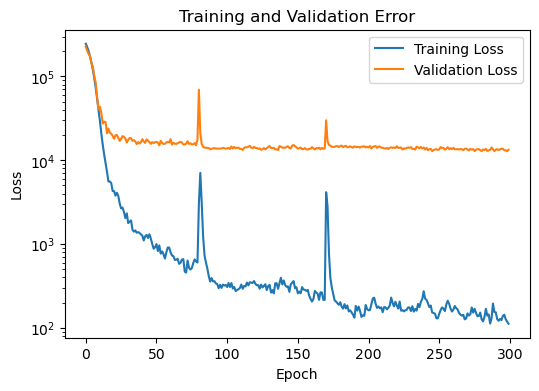

[np.float64(13329.31323910955)]
[np.float64(111.81969451904297)]


In [17]:
## Plot loss curves

fig = plt.figure(figsize=(6,4))
ax = fig.add_subplot(1, 1, 1)

ax.plot(range(len(train_loss_record)), train_loss_record, label="Training Loss")
ax.plot(range(len(validation_loss_record)), validation_loss_record, label="Validation Loss")

ax.set_yscale('log')
ax.set_title('Training and Validation Error')
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.legend()

plt.show()

print(validation_loss_record[-1:])
print(train_loss_record[-1:])

In [27]:
def label_to_box_xyxy(result, threshold=0.5):
    validation_result = []
    result_prob = []

    for ind_row in range(final_dim[0]):
        for ind_col in range(final_dim[1]):
            grid_info = grid_cell(ind_col, ind_row)
            conf = float(result[0, ind_row, ind_col])

            if conf >= threshold:
                c_x = grid_info[0] + anchor_size[1] / 2 + result[1, ind_row, ind_col]
                c_y = grid_info[1] + anchor_size[0] / 2 + result[2, ind_row, ind_col]
                w = result[3, ind_row, ind_col] * input_dim[1]
                h = result[4, ind_row, ind_col] * input_dim[0]

                # Skip invalid boxes
                if w <= 1 or h <= 1:
                    continue

                x1, y1, x2, y2 = bbox_convert(c_x, c_y, w, h)
                x1 = np.clip(x1, 0, input_dim[1] - 1)
                x2 = np.clip(x2, 0, input_dim[1] - 1)
                y1 = np.clip(y1, 0, input_dim[0] - 1)
                y2 = np.clip(y2, 0, input_dim[0] - 1)
                # Skip degenerate boxes after clipping
                if x2 <= x1 or y2 <= y1:
                    continue
                validation_result.append([x1, y1, x2, y2])
                result_prob.append(conf)
    if len(validation_result) == 0:
        return np.zeros((0, 4), dtype=np.float32), np.zeros((0,), dtype=np.float32)

    return np.array(validation_result, dtype=np.float32), np.array(result_prob, dtype=np.float32)


def voting_suppression(result_box, iou_threshold = 0.5):
    votes = np.zeros(result_box.shape[0])
    for ind, box in enumerate(result_box):
        for box_validation in result_box:
            if IoU(box_validation, box) > iou_threshold:
                votes[ind] += 1
    return (-votes).argsort()


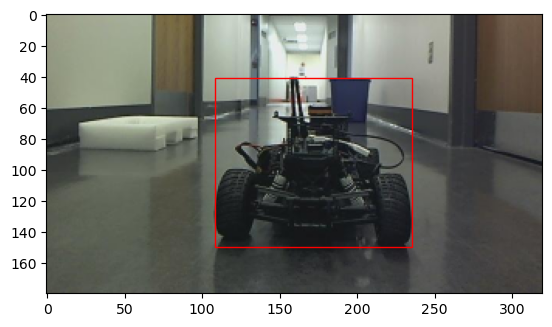

Image 0: selected bbox with score=0.7153770327568054, candidates=18


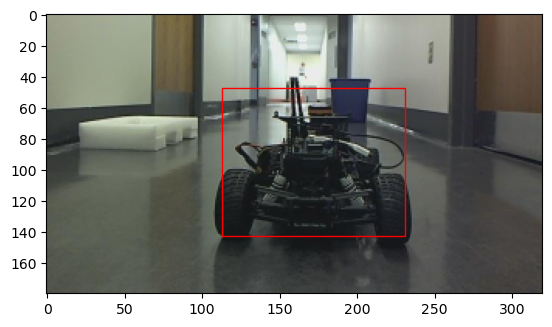

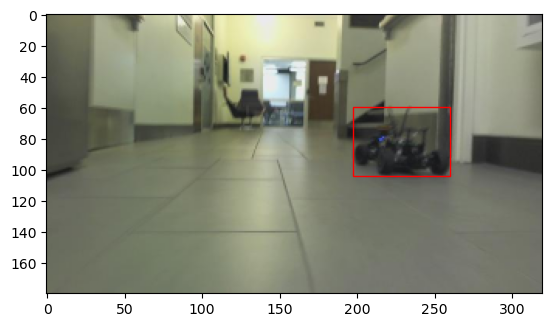

Image 1: selected bbox with score=0.7412432432174683, candidates=8


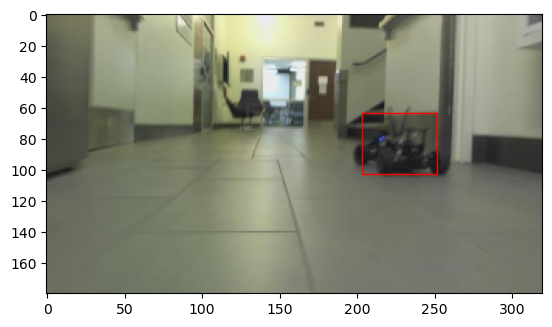

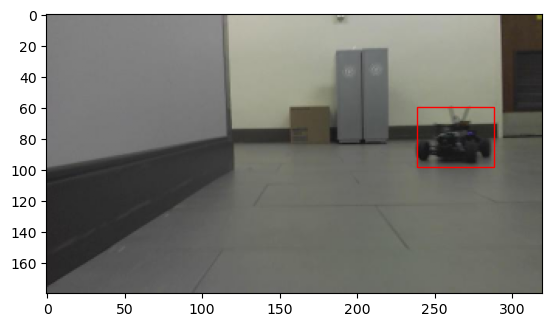

Image 2: selected bbox with score=0.3332595229148865, candidates=7


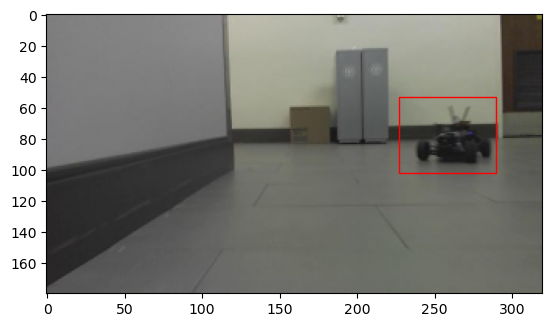

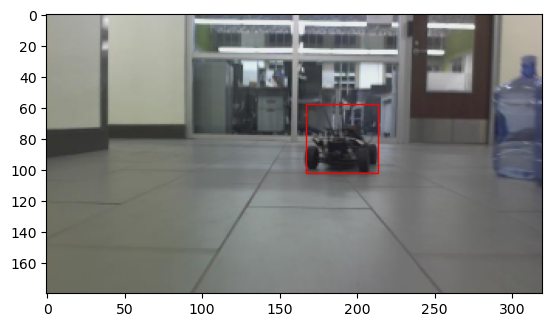

Image 3: selected bbox with score=0.31308645009994507, candidates=7


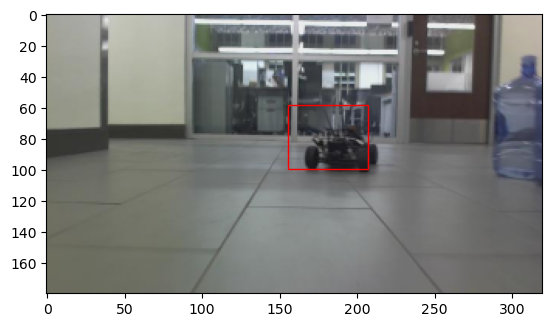

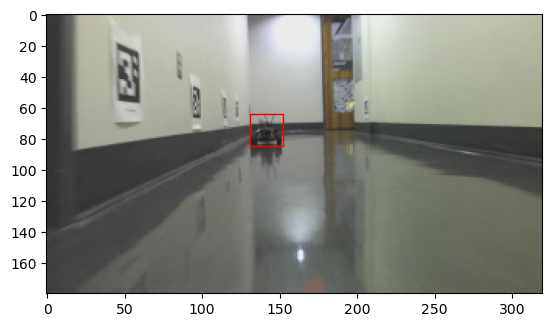

Image 4: selected bbox with score=0.5477345585823059, candidates=6


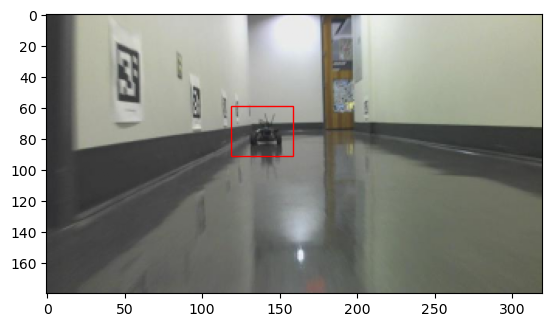

In [34]:
## Display some images in the validation set

model.eval()

voting_iou_threshold = 0.5
confi_threshold = 0.3   # lower this for visualization

with torch.no_grad():
    for data_ind, data_list in enumerate(validation_loader):
        image = data_list[0]
        label_gt = data_list[1]
        label = data_list[2]

        if data_ind == 5:
            break

        # Display ground truth
        DisplayLabel(np.transpose(image[0].numpy(), (1, 2, 0)), label)

        # Run model
        image_t = image.to(device)
        result = model(image_t)
        result = result.detach().cpu().numpy()

        bbox, score, num_boxes = get_best_bbox_from_result(
            result[0],
            confi_threshold=confi_threshold,
            voting_iou_threshold=voting_iou_threshold
        )

        if bbox is None:
            print(f"Image {data_ind}: no detection above confidence threshold {confi_threshold}")
            continue

        print(f"Image {data_ind}: selected bbox with score={score}, candidates={num_boxes}")

        [c_x, c_y, w, h] = bbox_convert_r(bbox[0], bbox[1], bbox[2], bbox[3])
        bboxs_2 = np.array([[c_x, c_y, w, h]])

        # Display prediction
        DisplayLabel(np.transpose(image[0].numpy(), (1, 2, 0)), bboxs_2)

In [35]:
def get_best_bbox_from_result(result_single, confi_threshold=0.4, voting_iou_threshold=0.5):
    """
    Converts one model output into the best predicted bbox.
    Returns:
        bbox: [x1, y1, x2, y2] or None
        score: confidence score or None
        num_boxes: number of candidate boxes above threshold
    """
    bboxs, result_prob = label_to_box_xyxy(result_single, confi_threshold)

    if bboxs.shape[0] == 0:
        return None, None, 0

    vote_rank = voting_suppression(bboxs, voting_iou_threshold)

    if len(vote_rank) == 0:
        return None, None, 0

    best_idx = vote_rank[0]
    bbox = bboxs[best_idx]

    score = result_prob[best_idx] if len(result_prob) > best_idx else None

    return bbox, score, bboxs.shape[0]


## Calculate accuracy safely

model.eval()

object_in_class = 0
truth_in_class = 0
missed_detections = 0

voting_iou_threshold = 0.5
confi_threshold = 0.5

ious = []
position_errors = []

with torch.no_grad():
    for data_ind, data_list in enumerate(validation_loader):
        image = data_list[0]
        label_gt = data_list[1]
        label = data_list[2]

        result = model(image.to(device))
        result = result.detach().cpu().numpy()

        bbox, score, num_boxes = get_best_bbox_from_result(
            result[0],
            confi_threshold=confi_threshold,
            voting_iou_threshold=voting_iou_threshold
        )

        truth_in_class += 1

        if bbox is None:
            missed_detections += 1
            continue

        [c_x, c_y, w, h] = bbox_convert_r(bbox[0], bbox[1], bbox[2], bbox[3])
        bboxs_2 = np.array([[c_x, c_y, w, h]])

        gt_cx = float(label[0][0])
        gt_cy = float(label[0][1])
        gt_w = float(label[0][2])
        gt_h = float(label[0][3])

        pos_change = np.sqrt((gt_cx - c_x) ** 2 + (gt_cy - c_y) ** 2)

        x_l, y_l, x_r, y_r = bbox_convert(gt_cx, gt_cy, gt_w, gt_h)
        label_xxyy = [x_l, y_l, x_r, y_r]

        iou = IoU(bbox, label_xxyy)

        ious.append(iou)
        position_errors.append(pos_change)

        if pos_change < 20 and iou > 0.5:
            object_in_class += 1

accuracy = object_in_class / truth_in_class
mean_iou = np.mean(ious) if len(ious) > 0 else 0.0
mean_position_error = np.mean(position_errors) if len(position_errors) > 0 else float("inf")
miss_rate = missed_detections / truth_in_class

print("accuracy:", accuracy)
print("mean IoU:", mean_iou)
print("mean position error:", mean_position_error)
print("missed detections:", missed_detections)
print("miss rate:", miss_rate)


accuracy: 0.9025069637883009
mean IoU: 0.7291431487580866
mean position error: 3.8783157
missed detections: 3
miss rate: 0.008356545961002786


### Ablation over thresholds

In [36]:
thresholds = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6]

threshold_results = []

for confi_threshold in thresholds:
    model.eval()

    object_in_class = 0
    truth_in_class = 0
    missed_detections = 0
    ious = []
    position_errors = []

    with torch.no_grad():
        for data_ind, data_list in enumerate(validation_loader):
            image = data_list[0]
            label = data_list[2]

            result = model(image.to(device))
            result = result.detach().cpu().numpy()

            bbox, score, num_boxes = get_best_bbox_from_result(
                result[0],
                confi_threshold=confi_threshold,
                voting_iou_threshold=0.5
            )

            truth_in_class += 1

            if bbox is None:
                missed_detections += 1
                continue

            [c_x, c_y, w, h] = bbox_convert_r(bbox[0], bbox[1], bbox[2], bbox[3])

            gt_cx = float(label[0][0])
            gt_cy = float(label[0][1])
            gt_w = float(label[0][2])
            gt_h = float(label[0][3])

            pos_change = np.sqrt((gt_cx - c_x) ** 2 + (gt_cy - c_y) ** 2)

            x_l, y_l, x_r, y_r = bbox_convert(gt_cx, gt_cy, gt_w, gt_h)
            label_xxyy = [x_l, y_l, x_r, y_r]

            iou = IoU(bbox, label_xxyy)

            ious.append(iou)
            position_errors.append(pos_change)

            if pos_change < 20 and iou > 0.5:
                object_in_class += 1

    accuracy = object_in_class / truth_in_class
    mean_iou = np.mean(ious) if len(ious) > 0 else 0.0
    mean_position_error = np.mean(position_errors) if len(position_errors) > 0 else np.nan
    miss_rate = missed_detections / truth_in_class

    threshold_results.append({
        "threshold": confi_threshold,
        "accuracy": accuracy,
        "mean_iou": mean_iou,
        "mean_position_error": mean_position_error,
        "miss_rate": miss_rate,
        "missed_detections": missed_detections,
        "total": truth_in_class
    })

threshold_results

[{'threshold': 0.1,
  'accuracy': 0.8245125348189415,
  'mean_iou': np.float64(0.6869206188471123),
  'mean_position_error': np.float32(9.183346),
  'miss_rate': 0.0,
  'missed_detections': 0,
  'total': 359},
 {'threshold': 0.2,
  'accuracy': 0.8523676880222841,
  'mean_iou': np.float64(0.6994948117525706),
  'mean_position_error': np.float32(6.8279033),
  'miss_rate': 0.002785515320334262,
  'missed_detections': 1,
  'total': 359},
 {'threshold': 0.3,
  'accuracy': 0.8774373259052924,
  'mean_iou': np.float64(0.7094605567314777),
  'mean_position_error': np.float32(6.2657666),
  'miss_rate': 0.002785515320334262,
  'missed_detections': 1,
  'total': 359},
 {'threshold': 0.4,
  'accuracy': 0.8941504178272981,
  'mean_iou': np.float64(0.723275681259545),
  'mean_position_error': np.float32(5.114291),
  'miss_rate': 0.002785515320334262,
  'missed_detections': 1,
  'total': 359},
 {'threshold': 0.5,
  'accuracy': 0.9025069637883009,
  'mean_iou': np.float64(0.7291431487580866),
  'mean_

Get table:

In [37]:
import pandas as pd

df_thresholds = pd.DataFrame(threshold_results)
df_thresholds

,threshold,accuracy,mean_iou,mean_position_error,miss_rate,missed_detections,total
0,0.1,0.824513,0.686921,9.183346,0.000000,0,359
1,0.2,0.852368,0.699495,6.827903,0.002786,1,359
2,0.3,0.877437,0.709461,6.265767,0.002786,1,359
3,0.4,0.894150,0.723276,5.114291,0.002786,1,359
4,0.5,0.902507,0.729143,3.878316,0.008357,3,359
5,0.6,0.894150,0.734995,4.976727,0.013928,5,359


In [38]:
df_thresholds.to_csv("../results/metrics/yolo_threshold_ablation.csv", index=False)